# Pipeline Lengkap Tugas 2 - Prediksi Arah USD/IDR dengan Fitur Pasar + NLP

**Kelompok Ayam Bakar Pak Yanto**
- Aloysius Pijar Hutama Indrianto (24/534591/PA/22675)
- Danar Fathurahman (24/5348200/PA/22828)
- Gilbert Nathaniel (24/533877/PA/22623)
- Satya Wira Pramudita (24/543649/PA/23102)

Notebook ini adalah versi **mandiri dan lengkap** dari pipeline Tugas 2. Seluruh kode ditulis inline di dalam notebook, dari inisialisasi sampai output: audit data, konstruksi target, fitur pasar, fitur sentimen (VADER + Loughran-McDonald), fitur TF-IDF, split kronologis dengan verifikasi leakage, pelatihan model, evaluasi, dan interpretasi.

## Pertanyaan riset

> Apakah informasi NLP dari berita geopolitik memberi sinyal prediktif tambahan untuk arah kurs USD/IDR hari berikutnya, di luar fitur historis kurs saja?

## Model yang dibandingkan

| Kode model | Fitur |
|---|---|
| `model0_market` | fitur pasar (lag return, moving average, volatilitas) |
| `model1_market_sentiment` | pasar + sentimen VADER & LM |
| `model2_market_tfidf` | pasar + TF-IDF + SVD |
| `model3_market_sentiment_tfidf` | pasar + sentimen + TF-IDF |
| `naive_all_up` / `naive_persistence` | baseline naif (selalu naik / arah hari sebelumnya) |

## Protokol anti-leakage

- **Target**: `target_next_up = 1` jika kurs hari perdagangan berikutnya lebih tinggi, selain itu 0 (flat dihitung 0).
- **Cutoff konservatif**: fitur hari `t` hanya memakai kurs `<= t` dan berita yang terbit **sebelum** hari `t` (aturan *next trading day* Tugas 1).
- **Split kronologis tanpa shuffle**: train s/d 2024-12-31, validation 2025, test 2026; test dievaluasi sekali.
- **Fitted state hanya dari train**: `StandardScaler`, `TfidfVectorizer`, dan `TruncatedSVD` selalu di-fit di dalam `Pipeline` pada data train.
- **Kolom turunan target dilarang sebagai fitur**: `rate_change`, `daily_return`, `has_geopolitical_news`, `article_ids`.

## Arsitektur pipeline

```mermaid
flowchart TD
    A["Data kurs USD/IDR (JISDOR BI)"] --> B["Market features: lag return, MA, volatilitas"]
    C["Berita geopolitik CNBC (14.941 artikel)"] --> D["Pembersihan teks (Tugas 1)"]
    D --> E["Sentimen VADER + Loughran-McDonald"]
    D --> F["TF-IDF + SVD (fit di train)"]
    B --> G["Agregasi harian + integrasi fitur (cutoff: berita terbit < hari t)"]
    E --> G
    F --> G
    G --> H["Logistic Regression + StandardScaler"]
    H --> I["Prediksi arah: naik / turun"]
    I --> J["Evaluasi: akurasi arah, F1, AUC, confusion matrix"]
```

Catatan: folder `src/` berisi implementasi modular dengan logika yang sama (dipakai oleh notebook 01 dan 02). Notebook ini adalah versi satu-file untuk keperluan penjelasan dan reproduksi end-to-end, dan menghasilkan output yang identik.

## Daftar isi

1. Inisialisasi dan konfigurasi
2. Audit dataset
3. Konstruksi target
4. Fitur pasar
5. Fitur sentimen (VADER + Loughran-McDonald)
6. Fitur TF-IDF
7. Split kronologis dan verifikasi leakage
8. Baseline naif dan model
9. Pemilihan text source TF-IDF
10. Pelatihan model0 - model3
11. Evaluasi
12. Analisis, konfigurasi, dan limitasi

In [1]:
from pathlib import Path
import csv
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysentiment2 as ps
from pysentiment2.utils import Tokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA_DIR = ROOT / "data"
CLEANED_DIR = DATA_DIR / "cleaned"
ALIGNED_DIR = DATA_DIR / "aligned"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

NEWS_CLEANED_CSV = CLEANED_DIR / "news_cleaned.csv"
NEWS_ALIGNMENT_CSV = ALIGNED_DIR / "news_alignment.csv"
DAILY_ALIGNED_CSV = ALIGNED_DIR / "daily_aligned_dataset.csv"
SENTIMENT_CSV = CLEANED_DIR / "news_sentiment.csv"
TRAIN_CSV = PROCESSED_DIR / "train.csv"
VALIDATION_CSV = PROCESSED_DIR / "validation.csv"
TEST_CSV = PROCESSED_DIR / "test.csv"
AUDIT_JSON = PROCESSED_DIR / "audit_summary.json"
PREDICTIONS_VALIDATION_CSV = REPORTS_DIR / "predictions_validation.csv"
PREDICTIONS_TEST_CSV = REPORTS_DIR / "predictions_test.csv"
RESULTS_VALIDATION_CSV = REPORTS_DIR / "results_validation.csv"
RESULTS_TEST_CSV = REPORTS_DIR / "results_test.csv"
RESULTS_TEXT_SOURCE_CSV = REPORTS_DIR / "results_text_source.csv"

RANDOM_SEED = 42
TARGET_COLUMN = "target_next_up"
TRAIN_END = "2024-12-31"
VALIDATION_END = "2025-12-31"
TEXT_SOURCES = ("title", "body", "title+body")
TFIDF_PARAMS = {"max_features": 5000, "min_df": 3, "ngram_range": (1, 2), "sublinear_tf": True}
SVD_COMPONENTS = 50
LOGISTIC_PARAMS = {"max_iter": 5000, "random_state": RANDOM_SEED}
FORCE_RECOMPUTE = False

MARKET_FEATURES = [
    "ret_1d",
    "ret_2d",
    "ret_3d",
    "ret_5d",
    "rate_to_ma5",
    "rate_to_ma20",
    "vol_5",
    "vol_20",
    "log_rate",
]

SENTIMENT_FEATURES = [
    "n_articles",
    "vader_mean",
    "vader_median",
    "vader_std",
    "vader_pos_ratio",
    "vader_neg_ratio",
    "vader_neutral_ratio",
    "lm_polarity_mean",
    "lm_polarity_median",
    "lm_polarity_std",
    "lm_pos_ratio",
    "lm_neg_ratio",
    "lm_neutral_ratio",
    "lm_negative_mean",
    "lm_positive_mean",
    "lm_uncertainty_mean",
    "lm_modal_mean",
]

FORBIDDEN_COLUMNS = {
    "rate_change",
    "daily_return",
    "has_geopolitical_news",
    "article_ids",
    "usd_idr_rate_next",
}

MODEL_SPECS = {
    "model0_market": {"market": True, "sentiment": False, "tfidf": False},
    "model1_market_sentiment": {"market": True, "sentiment": True, "tfidf": False},
    "model2_market_tfidf": {"market": True, "sentiment": False, "tfidf": True},
    "model3_market_sentiment_tfidf": {"market": True, "sentiment": True, "tfidf": True},
}

for directory in (PROCESSED_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("konfigurasi: seed", RANDOM_SEED, "| train s/d", TRAIN_END, "| validation s/d", VALIDATION_END)
print("google colab? tidak diperlukan; semua input dibaca dari folder data/ repo")

root: C:\Users\Satya\Desktop\tugas 1 NLP\NLP-Project
konfigurasi: seed 42 | train s/d 2024-12-31 | validation s/d 2025-12-31
google colab? tidak diperlukan; semua input dibaca dari folder data/ repo


## Langkah 1 - Audit dataset

Sebelum modeling, kita audit semua input yang dihasilkan Tugas 1:

- **Kurs**: `data/aligned/daily_aligned_dataset.csv` - JISDOR Bank Indonesia per hari perdagangan.
- **Berita**: `data/cleaned/news_cleaned.csv` + `data/aligned/news_alignment.csv` - artikel geopolitik CNBC yang sudah dibersihkan dan dipetakan ke hari perdagangan.

Yang diperiksa: jumlah baris, rentang tanggal, kolom, nilai hilang, duplikat, coverage berita per hari, distribusi jarak publikasi ke hari perdagangan (harus >= 1 hari), dan jeda libur pasar.

Hasil audit disimpan ke `data/processed/audit_summary.json` agar dapat dirujuk di laporan.

In [2]:
def count_csv_records(path):
    # csv.reader menghitung record logis, bukan baris fisik: isi artikel
    # mengandung newline di dalam field yang dikutip.
    with open(path, encoding="utf-8", newline="") as handle:
        return sum(1 for _ in csv.reader(handle)) - 1


def audit_dataset():
    daily = pd.read_csv(DAILY_ALIGNED_CSV, parse_dates=["trading_date"])
    alignment = pd.read_csv(NEWS_ALIGNMENT_CSV, parse_dates=["publication_date", "effective_trading_date"])
    lag_days = (alignment["effective_trading_date"] - alignment["publication_date"]).dt.days

    audit = {
        "exchange_rate": {
            "rows": int(len(daily)),
            "date_start": str(daily["trading_date"].min().date()),
            "date_end": str(daily["trading_date"].max().date()),
            "columns": list(daily.columns),
            "missing_values": {c: int(n) for c, n in daily.isna().sum().items() if n > 0},
            "duplicate_dates": int(daily["trading_date"].duplicated().sum()),
            "zero_change_days": int((daily["usd_idr_rate"].diff() == 0).sum()),
            "max_gap_days": int(daily["trading_date"].diff().dt.days.max()),
        },
        "news": {
            "cleaned_articles": count_csv_records(NEWS_CLEANED_CSV),
            "cleaned_columns": list(pd.read_csv(NEWS_CLEANED_CSV, nrows=0).columns),
            "published_wib_start": str(alignment["publication_date"].min().date()),
            "published_wib_end": str(alignment["publication_date"].max().date()),
        },
        "alignment": {
            "rows": int(len(alignment)),
            "rule": "next_trading_day (WIB)",
            "all_effective_after_publication": bool((alignment["effective_trading_date"] > alignment["publication_date"]).all()),
            "lag_days_distribution": {int(k): int(v) for k, v in lag_days.value_counts().sort_index().items()},
            "articles_per_trading_day": {
                "days_with_news": int((daily["geopolitical_news_count"] > 0).sum()),
                "days_without_news": int((daily["geopolitical_news_count"] == 0).sum()),
                "mean": round(float(daily["geopolitical_news_count"].mean()), 2),
                "median": float(daily["geopolitical_news_count"].median()),
                "max": int(daily["geopolitical_news_count"].max()),
            },
        },
        "conventions": {
            "market_timezone": "Asia/Jakarta (JISDOR terbit 00:00 WIB untuk hari tersebut)",
            "news_timezone": "Asia/Jakarta (dikonversi dari published_at_utc)",
            "information_cutoff": "fitur hari t hanya memakai kurs <= t dan berita terbit sebelum hari t",
            "target": f"{TARGET_COLUMN} = 1 jika kurs hari perdagangan berikutnya > kurs t; flat = 0",
        },
    }
    return audit, daily, alignment


audit, daily_raw, alignment = audit_dataset()
AUDIT_JSON.write_text(json.dumps(audit, indent=2), encoding="utf-8")

print("kurs:", audit["exchange_rate"]["rows"], "hari", audit["exchange_rate"]["date_start"], "s/d", audit["exchange_rate"]["date_end"])
print("nilai hilang kurs:", audit["exchange_rate"]["missing_values"], "| duplikat tanggal:", audit["exchange_rate"]["duplicate_dates"])
print("hari flat (perubahan 0):", audit["exchange_rate"]["zero_change_days"], "| jeda terpanjang antar hari perdagangan:", audit["exchange_rate"]["max_gap_days"], "hari (libur Idul Fitri)")
print("berita bersih:", audit["news"]["cleaned_articles"], "artikel | rentang publikasi WIB:", audit["news"]["published_wib_start"], "s/d", audit["news"]["published_wib_end"])
print("alignment:", audit["alignment"]["rows"], "baris | semua efektif setelah publikasi:", audit["alignment"]["all_effective_after_publication"])
print("berita per hari:", audit["alignment"]["articles_per_trading_day"])
print("contoh distribusi lag publikasi -> hari perdagangan (hari: jumlah):", dict(list(audit["alignment"]["lag_days_distribution"].items())[:8]), "...")
print("audit tersimpan ->", AUDIT_JSON.relative_to(ROOT))

kurs: 1202 hari 2021-09-01 s/d 2026-09-01
nilai hilang kurs: {'previous_rate': 1, 'rate_change': 1, 'daily_return': 1, 'article_ids': 1} | duplikat tanggal: 0
hari flat (perubahan 0): 13 | jeda terpanjang antar hari perdagangan: 12 hari (libur Idul Fitri)
berita bersih: 14941 artikel | rentang publikasi WIB: 2021-09-01 s/d 2026-08-31
alignment: 14941 baris | semua efektif setelah publikasi: True
berita per hari: {'days_with_news': 1201, 'days_without_news': 1, 'mean': 12.43, 'median': 10.0, 'max': 133}
contoh distribusi lag publikasi -> hari perdagangan (hari: jumlah): {1: 10262, 2: 1498, 3: 2375, 4: 366, 5: 202, 6: 70, 7: 52, 8: 40} ...
audit tersimpan -> data\processed\audit_summary.json


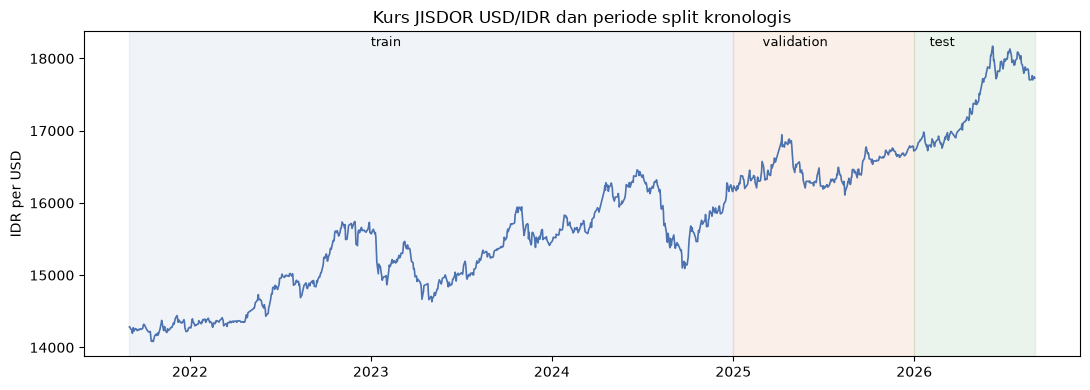

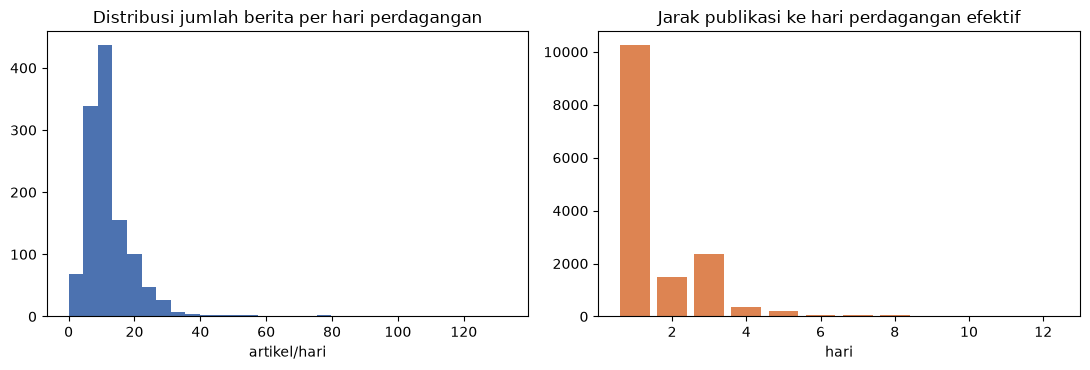

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_raw["trading_date"], daily_raw["usd_idr_rate"], color="#4c72b0", linewidth=1.2)
ax.axvspan(daily_raw["trading_date"].min(), pd.Timestamp(TRAIN_END), color="#4c72b0", alpha=0.08)
ax.axvspan(pd.Timestamp(TRAIN_END), pd.Timestamp(VALIDATION_END), color="#dd8452", alpha=0.12)
ax.axvspan(pd.Timestamp(VALIDATION_END), daily_raw["trading_date"].max(), color="#55a868", alpha=0.12)
ax.text(pd.Timestamp("2023-01-01"), daily_raw["usd_idr_rate"].max(), "train", fontsize=9)
ax.text(pd.Timestamp("2025-03-01"), daily_raw["usd_idr_rate"].max(), "validation", fontsize=9)
ax.text(pd.Timestamp("2026-02-01"), daily_raw["usd_idr_rate"].max(), "test", fontsize=9)
ax.set_title("Kurs JISDOR USD/IDR dan periode split kronologis")
ax.set_ylabel("IDR per USD")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_kurs_split.png", dpi=150)
plt.show()

lag_days = (alignment["effective_trading_date"] - alignment["publication_date"]).dt.days
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(daily_raw["geopolitical_news_count"], bins=30, color="#4c72b0")
axes[0].set_title("Distribusi jumlah berita per hari perdagangan")
axes[0].set_xlabel("artikel/hari")
lag_counts = lag_days.value_counts().sort_index()
axes[1].bar(lag_counts.index, lag_counts.values, color="#dd8452")
axes[1].set_title("Jarak publikasi ke hari perdagangan efektif")
axes[1].set_xlabel("hari")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_berita.png", dpi=150)
plt.show()

## Langkah 2 - Konstruksi target

Target mengikuti definisi AGENTS.md:

$$y_t = \begin{cases} 1, & \text{jika } kurs_{t+1} > kurs_t \\ 0, & \text{selainnya (turun atau flat)} \end{cases}$$

Catatan penting:

- `kurs_{t+1}` adalah kurs hari **perdagangan** berikutnya (bukan hari kalender), sehingga akhir pekan dan libur otomatis terlewati.
- Hari flat (perubahan tepat 0, ada 13 hari) dihitung kelas 0 dan tetap dipakai.
- Kolom `usd_idr_rate_next` hanya dipakai untuk membentuk label dan **tidak pernah** menjadi fitur (masuk daftar `FORBIDDEN_COLUMNS`).

In [4]:
def build_target(daily):
    df = daily.sort_values("trading_date").reset_index(drop=True).copy()
    next_rate = df["usd_idr_rate"].shift(-1)
    df["usd_idr_rate_next"] = next_rate
    target = (next_rate > df["usd_idr_rate"]).astype(float)
    target[next_rate.isna()] = np.nan
    df[TARGET_COLUMN] = target
    return df


frame = build_target(daily_raw)
print("hari flat (masuk kelas 0):", int((frame["usd_idr_rate"].diff() == 0).sum()))
print("baris tanpa label (hari terakhir):", int(frame[TARGET_COLUMN].isna().sum()))
print("rasio kelas naik sementara (semua baris berlabel):", round(float(frame[TARGET_COLUMN].mean()), 4))
frame[["trading_date", "usd_idr_rate", "usd_idr_rate_next", TARGET_COLUMN]].head(3)

hari flat (masuk kelas 0): 13
baris tanpa label (hari terakhir): 1
rasio kelas naik sementara (semua baris berlabel): 0.5537


,trading_date,usd_idr_rate,usd_idr_rate_next,target_next_up
0,2021-09-01,14284,14281.0,0.0
1,2021-09-02,14281,14261.0,0.0
2,2021-09-03,14261,14239.0,0.0


## Langkah 3 - Fitur pasar (9 fitur)

Semua fitur dihitung dari kurs yang **sudah diketahui pada hari `t`** (JISDOR terbit 00:00 WIB), dengan jendela yang berakhir di `t` - tidak ada `shift(-1)` atau statistik masa depan:

| Fitur | Deskripsi |
|---|---|
| `ret_1d`, `ret_2d`, `ret_3d`, `ret_5d` | return kurs 1/2/3/5 hari yang berakhir di `t` |
| `rate_to_ma5`, `rate_to_ma20` | deviasi kurs terhadap rata-rata bergerak 5/20 hari |
| `vol_5`, `vol_20` | volatilitas (std return) rolling 5/20 hari |
| `log_rate` | logaritma natural kurs `t` |

Baris 20 hari pertama akan gugur karena MA-20/vol-20 belum lengkap; hal ini ditangani setelah semua fitur digabung.

In [5]:
def build_market_features(daily):
    df = daily.sort_values("trading_date").reset_index(drop=True).copy()
    rate = df["usd_idr_rate"].astype(float)
    returns = rate.pct_change()

    # Semua fitur hanya memakai kurs <= t (JISDOR t terbit 00:00 WIB hari t).
    df["ret_1d"] = returns
    df["ret_2d"] = rate.pct_change(2)
    df["ret_3d"] = rate.pct_change(3)
    df["ret_5d"] = rate.pct_change(5)

    df["ma_5"] = rate.rolling(5).mean()
    df["ma_20"] = rate.rolling(20).mean()
    df["rate_to_ma5"] = rate / df["ma_5"] - 1.0
    df["rate_to_ma20"] = rate / df["ma_20"] - 1.0

    df["vol_5"] = returns.rolling(5).std()
    df["vol_20"] = returns.rolling(20).std()
    df["log_rate"] = np.log(rate)
    return df


frame = build_market_features(frame)
frame[["trading_date"] + MARKET_FEATURES].tail(3)

,trading_date,ret_1d,ret_2d,ret_3d,ret_5d,rate_to_ma5,rate_to_ma20,vol_5,vol_20,log_rate
1199,2026-08-28,-0.003322,-0.000790,0.000000,-0.004275,-0.000847,-0.008832,0.002820,0.002739,9.781489
1200,2026-08-31,0.002429,-0.000901,0.001637,0.002316,0.001117,-0.005500,0.002395,0.002847,9.783915
1201,2026-09-01,-0.001071,0.001356,-0.001970,0.001356,-0.000226,-0.005643,0.002489,0.002847,9.782844


## Langkah 4 - Fitur sentimen VADER + Loughran-McDonald (17 fitur)

Dua leksikon klasikal dijalankan pada judul + isi artikel:

- **VADER** (dirancang untuk teks pendek/informal): skor `compound` per artikel = rata-rata skor judul dan paragraf isi.
- **Loughran-McDonald (LM)** (dirancang untuk teks keuangan): frekuensi kategori `Negative`, `Positive`, `Uncertainty`, `Modal` per 1.000 token. Tokenisasi + stemming mengikuti `pysentiment2` dan stoplist ND. Polaritas = `(pos - neg) / (pos + neg + 1)`.

Kedua skor diagregasi ke level harian memakai `news_alignment.csv`: artikel dengan `effective_trading_date == t` adalah artikel yang terbit **sebelum** hari `t` (aturan next trading day). Dari sini dihitung:

- jumlah artikel (`n_articles`);
- rata-rata, median, simpangan baku skor VADER dan polaritas LM;
- rasio artikel positif / negatif / netral (VADER: compound > 0,05 / < -0,05; LM: polaritas > 0 / < 0);
- rata-rata kategori LM (negative, positive, uncertainty, modal) per 1.000 token.

Skor tingkat artikel di-cache ke `data/cleaned/news_sentiment.csv`; ubah `FORCE_RECOMPUTE = True` di sel inisialisasi untuk menghitung ulang (sekitar 3-5 menit untuk 14.941 artikel).

In [6]:
LM_CATEGORIES = ["Negative", "Positive", "Uncertainty", "Modal"]
VADER_POS_THRESHOLD = 0.05
VADER_NEG_THRESHOLD = -0.05


def stem_first(tokenizer, word):
    tokens = tokenizer.tokenize(str(word))
    return tokens[0] if tokens else None


def load_lm_category_sets(tokenizer):
    data = pd.read_csv(Path(ps.__file__).resolve().parent / "static" / "LM.csv", usecols=["Word"] + LM_CATEGORIES)
    category_sets = {}
    for category in LM_CATEGORIES:
        words = data.loc[data[category] > 0, "Word"].apply(lambda w: stem_first(tokenizer, w)).dropna()
        category_sets[category] = set(words)
    return category_sets


def vader_article_score(sia, title, content):
    paragraphs = [str(title)] + [p for p in str(content).split("\n") if p.strip()]
    compounds = [sia.polarity_scores(p)["compound"] for p in paragraphs]
    return float(np.mean(compounds)) if compounds else 0.0


def lm_article_scores(tokenizer, category_sets, title, content):
    tokens = tokenizer.tokenize(str(title) + "\n" + str(content))
    n_tokens = len(tokens)
    counts = {category: 0 for category in LM_CATEGORIES}
    for token in tokens:
        for category, words in category_sets.items():
            if token in words:
                counts[category] += 1
    per_1k = 1000.0 / max(n_tokens, 1)
    pos = counts["Positive"]
    neg = counts["Negative"]
    return {
        "lm_polarity": (pos - neg) / (pos + neg + 1.0),
        "lm_negative": neg * per_1k,
        "lm_positive": pos * per_1k,
        "lm_uncertainty": counts["Uncertainty"] * per_1k,
        "lm_modal": counts["Modal"] * per_1k,
        "lm_tokens": float(n_tokens),
    }


def score_articles(force=False):
    if SENTIMENT_CSV.exists() and not force:
        scores = pd.read_csv(SENTIMENT_CSV)
        print("skor sentimen dimuat dari cache:", SENTIMENT_CSV.name, "|", len(scores), "artikel")
        return scores
    print("skor sentimen artikel (VADER + LM, teks title+body): mulai")
    news = pd.read_csv(NEWS_CLEANED_CSV, usecols=["article_id", "title_clean", "content_clean"])
    sia = SentimentIntensityAnalyzer()
    tokenizer = Tokenizer()
    category_sets = load_lm_category_sets(tokenizer)
    rows = []
    for i, row in enumerate(news.itertuples(index=False), 1):
        scores_row = {"article_id": row.article_id}
        scores_row["vader_score"] = vader_article_score(sia, row.title_clean, row.content_clean)
        scores_row.update(lm_article_scores(tokenizer, category_sets, row.title_clean, row.content_clean))
        rows.append(scores_row)
        if i % 3000 == 0:
            print(f"  {i}/{len(news)} artikel")
    out = pd.DataFrame(rows)
    out.to_csv(SENTIMENT_CSV, index=False)
    print("skor tersimpan ->", SENTIMENT_CSV.name)
    return out


def build_daily_sentiment(force=False):
    alignment_scores = pd.read_csv(NEWS_ALIGNMENT_CSV, usecols=["article_id", "effective_trading_date"], parse_dates=["effective_trading_date"])
    scores = score_articles(force=force)
    merged = alignment_scores.merge(scores, on="article_id", how="inner")

    merged["vader_pos"] = (merged["vader_score"] > VADER_POS_THRESHOLD).astype(float)
    merged["vader_neg"] = (merged["vader_score"] < VADER_NEG_THRESHOLD).astype(float)
    merged["vader_neutral"] = 1.0 - merged["vader_pos"] - merged["vader_neg"]
    merged["lm_pos"] = (merged["lm_polarity"] > 0).astype(float)
    merged["lm_neg"] = (merged["lm_polarity"] < 0).astype(float)
    merged["lm_neutral"] = 1.0 - merged["lm_pos"] - merged["lm_neg"]

    daily = (
        merged.groupby("effective_trading_date")
        .agg(
            n_articles=("article_id", "size"),
            vader_mean=("vader_score", "mean"),
            vader_median=("vader_score", "median"),
            vader_std=("vader_score", "std"),
            vader_pos_ratio=("vader_pos", "mean"),
            vader_neg_ratio=("vader_neg", "mean"),
            vader_neutral_ratio=("vader_neutral", "mean"),
            lm_polarity_mean=("lm_polarity", "mean"),
            lm_polarity_median=("lm_polarity", "median"),
            lm_polarity_std=("lm_polarity", "std"),
            lm_pos_ratio=("lm_pos", "mean"),
            lm_neg_ratio=("lm_neg", "mean"),
            lm_neutral_ratio=("lm_neutral", "mean"),
            lm_negative_mean=("lm_negative", "mean"),
            lm_positive_mean=("lm_positive", "mean"),
            lm_uncertainty_mean=("lm_uncertainty", "mean"),
            lm_modal_mean=("lm_modal", "mean"),
        )
        .reset_index()
        .rename(columns={"effective_trading_date": "trading_date"})
    )
    return daily


daily_sentiment = build_daily_sentiment(force=FORCE_RECOMPUTE)
print("agregasi sentimen harian:", daily_sentiment.shape, "| rentang:", daily_sentiment["trading_date"].min().date(), "s/d", daily_sentiment["trading_date"].max().date())
daily_sentiment[["trading_date", "n_articles", "vader_mean", "vader_neg_ratio", "lm_polarity_mean", "lm_uncertainty_mean"]].head(3)

skor sentimen dimuat dari cache: news_sentiment.csv | 14941 artikel
agregasi sentimen harian: (1201, 18) | rentang: 2021-09-02 s/d 2026-09-01


,trading_date,n_articles,vader_mean,vader_neg_ratio,lm_polarity_mean,lm_uncertainty_mean
0,2021-09-02,10,-0.002690,0.300000,-0.371307,17.546241
1,2021-09-03,11,0.112946,0.181818,-0.439334,9.644439
2,2021-09-06,21,0.099699,0.190476,-0.277389,19.699676


## Langkah 5 - Fitur TF-IDF (50 komponen)

Representasi teks kedua adalah TF-IDF klasikal:

1. Setiap hari perdagangan menjadi **satu dokumen**: gabungan seluruh artikel yang terbit sebelum hari itu (cutoff yang sama dengan sentimen).
2. `TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1,2), sublinear_tf=True)` diubah menjadi 50 komponen `TruncatedSVD` + `StandardScaler`.
3. Vocabulary, IDF, dan komponen SVD adalah *fitted state*: semuanya di-fit di dalam `Pipeline` pada data **train saja**.

Tiga opsi teks dibandingkan pada validation di langkah 9: `title`, `body`, dan `title+body`. Hasilnya dipilih berdasarkan F1 macro validation dan dipakai untuk laporan akhir.

In [7]:
def build_daily_text(text_source):
    if text_source not in {"title", "body", "title+body"}:
        raise ValueError(f"text_source tidak dikenal: {text_source}")
    news = pd.read_csv(NEWS_CLEANED_CSV, usecols=["article_id", "title_clean", "content_clean"])
    alignment_text = pd.read_csv(NEWS_ALIGNMENT_CSV, usecols=["article_id", "effective_trading_date"], parse_dates=["effective_trading_date"])
    merged = alignment_text.merge(news, on="article_id", how="inner")

    # Dokumen harian hanya dari berita yang sudah terbit sebelum hari perdagangan t
    # (alignment next trading day), sehingga TF-IDF tidak melihat teks masa depan.
    if text_source == "title":
        text = merged["title_clean"].fillna("")
    elif text_source == "body":
        text = merged["content_clean"].fillna("")
    else:
        text = merged["title_clean"].fillna("") + "\n" + merged["content_clean"].fillna("")
    merged["text"] = text

    daily = merged.groupby("effective_trading_date")["text"].apply(lambda parts: "\n".join(parts))
    daily = daily.rename_axis("trading_date").reset_index().rename(columns={"text": "daily_text"})
    return daily


def build_text_pipeline():
    return Pipeline(
        [
            ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
            ("svd", TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_SEED)),
            ("scaler", StandardScaler()),
        ]
    )


docs_preview = build_daily_text("title+body")
print("dokumen harian:", len(docs_preview), "| contoh tanggal:", docs_preview["trading_date"].min().date(), "s/d", docs_preview["trading_date"].max().date())
print("contoh potongan dokumen:")
print(docs_preview.loc[0, "daily_text"][:350], "...")

dokumen harian: 1201 | contoh tanggal: 2021-09-02 s/d 2026-09-01
contoh potongan dokumen:
The world could see another 9/11 if it abandons Afghanistan, peace negotiator says
A repeat of the devastating Sept. 11, 2001 terrorist attacks could happen if the international community abandons Afghanistan, a peace negotiator for Afghanistan told CNBC.
The U.S. on Monday announced that the last evacuation flight had left Kabul , marking the fina ...


## Langkah 6 - Split kronologis dan verifikasi leakage

Split dibuat dari urutan waktu, **tanpa shuffle**:

| Split | Periode | Fungsi |
|---|---|---|
| train | s/d 2024-12-31 | melatih model dan fitted state (scaler, TF-IDF, SVD) |
| validation | 2025 | memilih konfigurasi (text source); tidak menyentuh test |
| test | 2026 | evaluasi final, hanya sekali |

Verifikasi yang dijalankan:

1. Kolom terlarang (`rate_change`, `daily_return`, dst.) tidak ada di daftar fitur.
2. Tidak ada NaN pada fitur setelah baris histori/label tidak lengkap dibuang.
3. Urutan split benar-benar kronologis dan tidak tumpang tindih.
4. Target dihitung ulang dari `usd_idr_rate_next` dan harus sama persis.
5. Semua artikel yang dipakai terbit sebelum hari perdagangan efektifnya.

Dataset hasil split disimpan ke `data/processed/{train,validation,test}.csv`.

In [8]:
def assemble_modeling_frame(frame, sentiment):
    merged = frame.merge(sentiment, on="trading_date", how="left")
    merged[SENTIMENT_FEATURES] = merged[SENTIMENT_FEATURES].fillna(0.0)
    before = len(merged)
    merged = merged.dropna(subset=MARKET_FEATURES + [TARGET_COLUMN]).reset_index(drop=True)
    merged[TARGET_COLUMN] = merged[TARGET_COLUMN].astype(int)
    print("baris terbuang (histori < 20 hari atau label besok tidak ada):", before - len(merged))
    return merged


def split_frame(frame):
    train = frame[frame["trading_date"] <= TRAIN_END].reset_index(drop=True)
    validation = frame[(frame["trading_date"] > TRAIN_END) & (frame["trading_date"] <= VALIDATION_END)].reset_index(drop=True)
    test = frame[frame["trading_date"] > VALIDATION_END].reset_index(drop=True)
    return train, validation, test


def verify_frame(frame, train, validation, test):
    features = MARKET_FEATURES + SENTIMENT_FEATURES
    leaked = FORBIDDEN_COLUMNS.intersection(features)
    assert not leaked, f"kolom terlarang dipakai sebagai fitur: {leaked}"
    assert frame[features].notna().all().all(), "fitur mengandung NaN"
    assert train["trading_date"].max() < validation["trading_date"].min(), "split train/validation tidak kronologis"
    assert validation["trading_date"].max() < test["trading_date"].min(), "split validation/test tidak kronologis"
    recomputed = (frame["usd_idr_rate_next"] > frame["usd_idr_rate"]).astype(int)
    assert (recomputed == frame[TARGET_COLUMN]).all(), "target tidak konsisten"
    assert (alignment["publication_date"] < alignment["effective_trading_date"]).all(), "berita dipakai sebelum terbit"
    print("verifikasi leakage: lolos (fitur aman, split kronologis, cutoff berita benar)")


def summarize_split(name, split):
    return {
        "split": name,
        "rows": int(len(split)),
        "date_start": str(split["trading_date"].min().date()),
        "date_end": str(split["trading_date"].max().date()),
        "up_ratio": round(float(split[TARGET_COLUMN].mean()), 3),
    }


frame = assemble_modeling_frame(frame, daily_sentiment)
train, validation, test = split_frame(frame)
verify_frame(frame, train, validation, test)

save_columns = ["trading_date", "usd_idr_rate"] + MARKET_FEATURES + SENTIMENT_FEATURES + [TARGET_COLUMN]
train[save_columns].to_csv(TRAIN_CSV, index=False)
validation[save_columns].to_csv(VALIDATION_CSV, index=False)
test[save_columns].to_csv(TEST_CSV, index=False)

summary = pd.DataFrame([summarize_split("train", train), summarize_split("validation", validation), summarize_split("test", test)])
print("dataset split disimpan -> data/processed/{train,validation,test}.csv")
summary

baris terbuang (histori < 20 hari atau label besok tidak ada): 21
verifikasi leakage: lolos (fitur aman, split kronologis, cutoff berita benar)
dataset split disimpan -> data/processed/{train,validation,test}.csv


,split,rows,date_start,date_end,up_ratio
0,train,790,2021-09-29,2024-12-31,0.562
1,validation,237,2025-01-02,2025-12-31,0.523
2,test,154,2026-01-02,2026-08-31,0.571


## Langkah 7 - Baseline naif dan model

Kita memakai estimator yang sama untuk semua eksperimen agar perbandingan adil:

- **Baseline naif**: `naive_all_up` (selalu prediksi naik) dan `naive_persistence` (prediksi mengikuti arah pergerakan hari sebelumnya) - sebagai konteks apakah model benar-benar belajar sesuatu.
- **Model utama**: `LogisticRegression(max_iter=5000, random_state=42)` di dalam `Pipeline` dengan `StandardScaler` (fitur numerik) dan `ColumnTransformer` yang juga bisa memuat blok TF-IDF.

Metrik yang dihitung: akurasi arah, F1 kelas naik, F1 macro, MCC, dan ROC AUC.

In [9]:
def naive_predictions(frame):
    return {
        "naive_all_up": np.ones(len(frame), dtype=int),
        "naive_persistence": (frame["ret_1d"].to_numpy() > 0).astype(int),
    }


def build_estimator(spec):
    numeric_features = []
    if spec["market"]:
        numeric_features += MARKET_FEATURES
    if spec["sentiment"]:
        numeric_features += SENTIMENT_FEATURES

    transformers = []
    if numeric_features:
        transformers.append(("numeric", StandardScaler(), numeric_features))
    if spec["tfidf"]:
        transformers.append(("tfidf", build_text_pipeline(), "daily_text"))
    if not transformers:
        raise ValueError("model tanpa fitur")

    preprocessor = ColumnTransformer(transformers)
    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("logistic", LogisticRegression(**LOGISTIC_PARAMS)),
        ]
    )


def fit_predict(spec, train_frame, eval_frame):
    estimator = build_estimator(spec)
    estimator.fit(train_frame, train_frame[TARGET_COLUMN])
    proba = estimator.predict_proba(eval_frame)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return pred, proba


def compute_metrics(y_true, y_pred, y_proba=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    metrics = {
        "directional_accuracy": accuracy_score(y_true, y_pred),
        "f1_up": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    if y_proba is not None and len(np.unique(y_true)) > 1:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        metrics["roc_auc"] = np.nan
    return metrics


def append_predictions(store, model_name, frame_data, pred, proba):
    for date, y_true, y_pred, y_proba in zip(frame_data["trading_date"].dt.strftime("%Y-%m-%d"), frame_data[TARGET_COLUMN], pred, proba):
        store.append({"model": model_name, "trading_date": date, "y_true": int(y_true), "y_pred": int(y_pred), "y_proba": float(y_proba)})


def attach_text(split, daily_text):
    merged = split.merge(daily_text, on="trading_date", how="left")
    merged["daily_text"] = merged["daily_text"].fillna("")
    return merged


print("helper model siap: baseline naif, pipeline logistik, metrik, dan agregasi prediksi")

helper model siap: baseline naif, pipeline logistik, metrik, dan agregasi prediksi


## Langkah 8 - Pemilihan text source TF-IDF pada validation

Keputusan eksplisit yang diminta AGENTS.md: field teks mana yang dipakai TF-IDF? Kita bandingkan tiga opsi memakai model terlengkap (`model3`: pasar + sentimen + TF-IDF) pada validation 2025:

- `title` - hanya judul,
- `body` - hanya isi artikel,
- `title+body` - gabungan keduanya.

Aturan pemilihan: F1 macro validation tertinggi, seri diputus oleh akurasi arah. Konfigurasi terpilih dipakai untuk semua model final; test tidak disentuh pada tahap ini.

In [10]:
rows = []
for source in TEXT_SOURCES:
    daily_text_source = build_daily_text(source)
    train_text = attach_text(train, daily_text_source)
    validation_text = attach_text(validation, daily_text_source)
    pred, proba = fit_predict(MODEL_SPECS["model3_market_sentiment_tfidf"], train_text, validation_text)
    rows.append({"text_source": source, **compute_metrics(validation_text[TARGET_COLUMN], pred, proba)})

results_text_source = pd.DataFrame(rows).sort_values(["f1_macro", "directional_accuracy"], ascending=False).reset_index(drop=True)
results_text_source.to_csv(RESULTS_TEXT_SOURCE_CSV, index=False)
chosen_text_source = str(results_text_source.loc[0, "text_source"])
print("text source terpilih:", chosen_text_source)
results_text_source.round(4)

text source terpilih: title+body


,text_source,directional_accuracy,f1_up,f1_macro,mcc,roc_auc
0,title+body,0.5232,0.5311,0.5231,0.0471,0.5124
1,title,0.5359,0.6071,0.5201,0.0602,0.5328
2,body,0.5190,0.5000,0.5183,0.0440,0.5114


## Langkah 9 - Pelatihan model0 sampai model3

Dengan text source terpilih, kita latih empat model pada train dan prediksi validation + test sekaligus, ditambah dua baseline naif. Prediksi mentah disimpan ke `reports/predictions_{validation,test}.csv` supaya evaluasi bisa dijalankan ulang tanpa melatih ulang.

Model yang dilatih hanya memakai train. Tidak ada hyperparameter yang dituning terhadap test.

In [11]:
daily_text = build_daily_text(chosen_text_source)
train_text = attach_text(train, daily_text)
validation_text = attach_text(validation, daily_text)
test_text = attach_text(test, daily_text)

predictions_validation, predictions_test = [], []
for model_name, spec in MODEL_SPECS.items():
    pred_validation, proba_validation = fit_predict(spec, train_text, validation_text)
    append_predictions(predictions_validation, model_name, validation_text, pred_validation, proba_validation)
    pred_test, proba_test = fit_predict(spec, train_text, test_text)
    append_predictions(predictions_test, model_name, test_text, pred_test, proba_test)

for naive_name, pred in naive_predictions(validation_text).items():
    append_predictions(predictions_validation, naive_name, validation_text, pred, pred.astype(float))
for naive_name, pred in naive_predictions(test_text).items():
    append_predictions(predictions_test, naive_name, test_text, pred, pred.astype(float))

predictions_validation = pd.DataFrame(predictions_validation)
predictions_test = pd.DataFrame(predictions_test)
predictions_validation.to_csv(PREDICTIONS_VALIDATION_CSV, index=False)
predictions_test.to_csv(PREDICTIONS_TEST_CSV, index=False)

print("prediksi tersimpan ->", PREDICTIONS_VALIDATION_CSV.name, "dan", PREDICTIONS_TEST_CSV.name)
print("jumlah baris: validation", len(predictions_validation), "| test", len(predictions_test))
for name, predictions in [("validation 2025", predictions_validation), ("test 2026", predictions_test)]:
    summary = pd.DataFrame(
        [{"model": model, "n": len(group), **compute_metrics(group["y_true"], group["y_pred"], group["y_proba"])} for model, group in predictions.groupby("model", sort=False)]
    )
    # Baseline naif tetap dihitung dan tersimpan di CSV prediksi, tetapi
    # tidak ditampilkan di tabel ringkasan agar fokus pada model0-model3.
    summary_models = summary[summary["model"].str.startswith("model")]
    print(f"--- ringkasan metrik {name} (model0-model3) ---")
    print(summary_models.round(4).to_string(index=False))

prediksi tersimpan -> predictions_validation.csv dan predictions_test.csv
jumlah baris: validation 1422 | test 924
--- ringkasan metrik validation 2025 (model0-model3) ---
                        model   n  directional_accuracy  f1_up  f1_macro     mcc  roc_auc
                model0_market 237                0.5232 0.6319    0.4776  0.0252   0.5081
      model1_market_sentiment 237                0.4937 0.6129    0.4406 -0.0476   0.5094
          model2_market_tfidf 237                0.4726 0.4589    0.4722 -0.0506   0.4843
model3_market_sentiment_tfidf 237                0.5232 0.5311    0.5231  0.0471   0.5124
--- ringkasan metrik test 2026 (model0-model3) ---
                        model   n  directional_accuracy  f1_up  f1_macro    mcc  roc_auc
                model0_market 154                0.5455 0.6354    0.5160 0.0440   0.5666
      model1_market_sentiment 154                0.5779 0.6948    0.5053 0.0863   0.5504
          model2_market_tfidf 154                0.5130 0.45

## Langkah 10 - Evaluasi dan figure

Metrik final dihitung dari file prediksi (bukan dari model yang masih di memori), lalu disimpan ke `reports/results_validation.csv` dan `reports/results_test.csv`. Figure yang dibuat:

1. Perbandingan akurasi / F1 macro / ROC AUC antar model pada test.
2. Confusion matrix test per model.
3. Kurva ROC test per model.
4. **Overlay prediksi dengan data aktual**: kurs JISDOR test dengan shading prediksi model3, plus panel per model berisi return harian aktual dan penanda arah prediksi (hijau benar, merah salah).
5. Diagram arsitektur pipeline.

Metrik utama adalah akurasi arah dan F1; AUC/MCC membantu karena kelas tidak sepenuhnya seimbang dan baseline selalu-naik sulit dikalahkan pada akurasi.

In [12]:
def summarize_predictions(predictions):
    return pd.DataFrame(
        [{"model": model, "n": len(group), **compute_metrics(group["y_true"], group["y_pred"], group["y_proba"])} for model, group in predictions.groupby("model", sort=False)]
    )


results_validation = summarize_predictions(predictions_validation)
results_test = summarize_predictions(predictions_test)
results_validation.to_csv(RESULTS_VALIDATION_CSV, index=False)
results_test.to_csv(RESULTS_TEST_CSV, index=False)

print("== validation 2025 (model0-model3) ==")
print(results_validation[results_validation["model"].str.startswith("model")].round(4).to_string(index=False))
print("== test 2026 (model0-model3) ==")
print(results_test[results_test["model"].str.startswith("model")].round(4).to_string(index=False))
print("tabel hasil ->", RESULTS_VALIDATION_CSV.name, "dan", RESULTS_TEST_CSV.name)

== validation 2025 (model0-model3) ==
                        model   n  directional_accuracy  f1_up  f1_macro     mcc  roc_auc
                model0_market 237                0.5232 0.6319    0.4776  0.0252   0.5081
      model1_market_sentiment 237                0.4937 0.6129    0.4406 -0.0476   0.5094
          model2_market_tfidf 237                0.4726 0.4589    0.4722 -0.0506   0.4843
model3_market_sentiment_tfidf 237                0.5232 0.5311    0.5231  0.0471   0.5124
== test 2026 (model0-model3) ==
                        model   n  directional_accuracy  f1_up  f1_macro    mcc  roc_auc
                model0_market 154                0.5455 0.6354    0.5160 0.0440   0.5666
      model1_market_sentiment 154                0.5779 0.6948    0.5053 0.0863   0.5504
          model2_market_tfidf 154                0.5130 0.4526    0.5070 0.0845   0.5479
model3_market_sentiment_tfidf 154                0.5130 0.4526    0.5070 0.0845   0.5682
tabel hasil -> results_validation.c

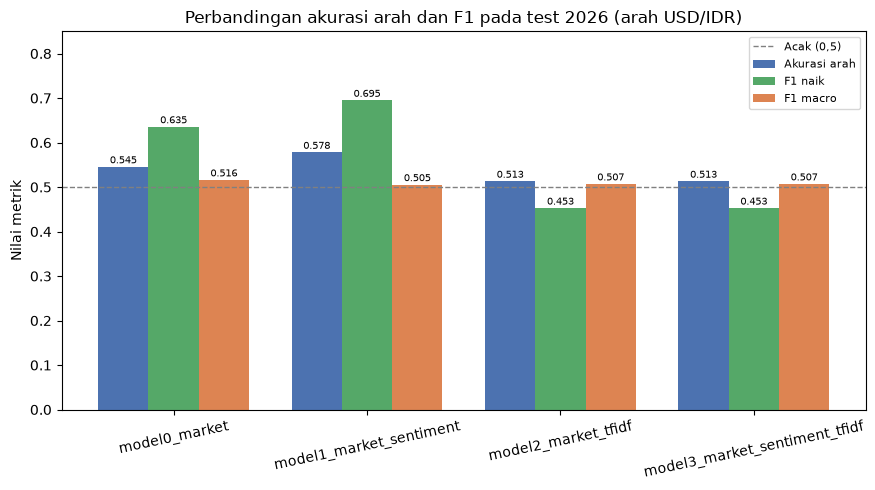

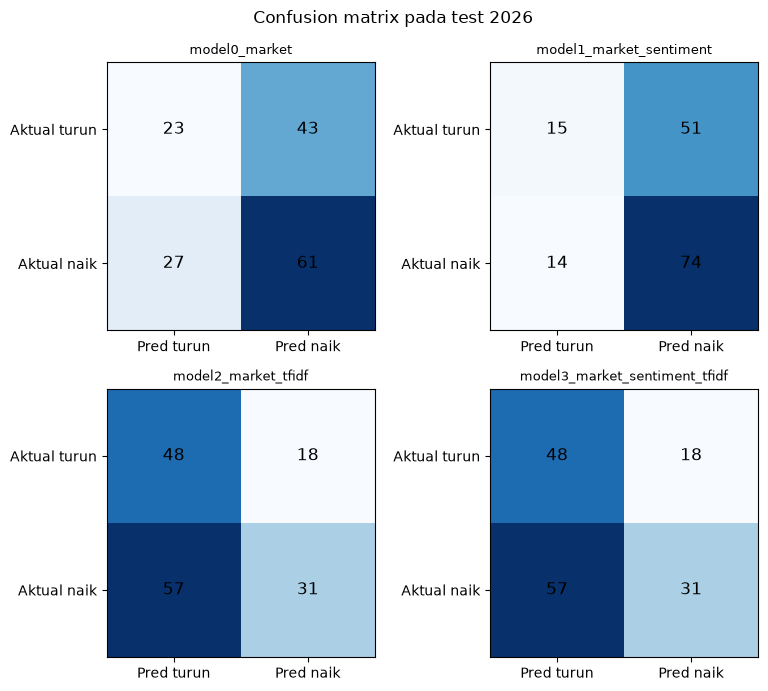

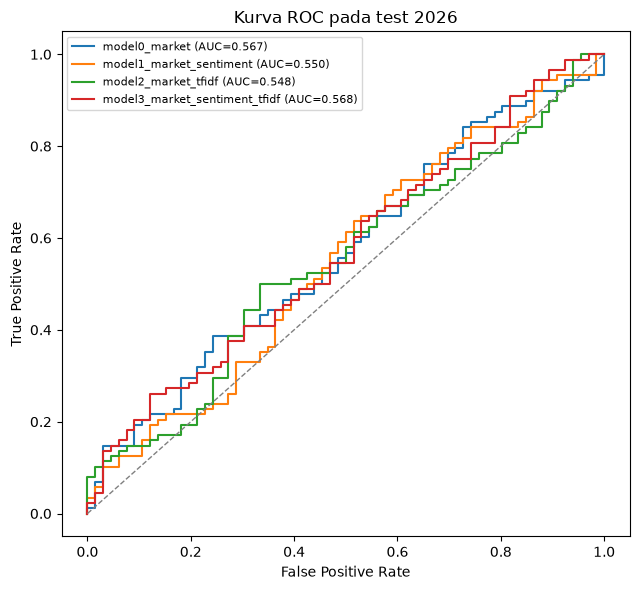

In [13]:
def plot_metrics_comparison(results_test):
    model_results = results_test[results_test["model"].str.startswith("model")].reset_index(drop=True)
    x = np.arange(len(model_results))
    width = 0.26
    fig, ax = plt.subplots(figsize=(9, 5))
    for offset, metric, label, color in [
        (-width, "directional_accuracy", "Akurasi arah", "#4c72b0"),
        (0.0, "f1_up", "F1 naik", "#55a868"),
        (width, "f1_macro", "F1 macro", "#dd8452"),
    ]:
        values = model_results[metric].to_numpy()
        ax.bar(x + offset, values, width, label=label, color=color)
        for xi, value in zip(x + offset, values):
            if np.isfinite(value):
                ax.text(xi, value + 0.008, f"{value:.3f}", ha="center", fontsize=7)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Acak (0,5)")
    ax.set_xticks(x)
    ax.set_xticklabels(model_results["model"], rotation=12)
    ax.set_ylim(0.0, 0.85)
    ax.set_ylabel("Nilai metrik")
    ax.set_title("Perbandingan akurasi arah dan F1 pada test 2026 (arah USD/IDR)")
    ax.legend(fontsize=8, loc="upper right")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "metrics_comparison_test.png", dpi=150)
    plt.show()


def plot_confusion_matrices(predictions_test):
    model_names = [name for name in predictions_test["model"].unique() if name.startswith("model")]
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    for ax, model_name in zip(axes.ravel(), model_names):
        group = predictions_test[predictions_test["model"] == model_name]
        matrix = confusion_matrix(group["y_true"], group["y_pred"], labels=[0, 1])
        ax.imshow(matrix, cmap="Blues")
        for row in range(2):
            for col in range(2):
                ax.text(col, row, str(matrix[row, col]), ha="center", va="center", fontsize=12)
        ax.set_xticks([0, 1], labels=["Pred turun", "Pred naik"])
        ax.set_yticks([0, 1], labels=["Aktual turun", "Aktual naik"])
        ax.set_title(model_name, fontsize=9)
    fig.suptitle("Confusion matrix pada test 2026")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "confusion_matrix_test.png", dpi=150)
    plt.show()


def plot_roc_curves(predictions_test):
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for model_name, group in predictions_test.groupby("model", sort=False):
        if not model_name.startswith("model"):
            continue
        fpr, tpr, _ = roc_curve(group["y_true"], group["y_proba"])
        auc_value = roc_auc_score(group["y_true"], group["y_proba"])
        ax.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Kurva ROC pada test 2026")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "roc_test.png", dpi=150)
    plt.show()


plot_metrics_comparison(results_test)
plot_confusion_matrices(predictions_test)
plot_roc_curves(predictions_test)

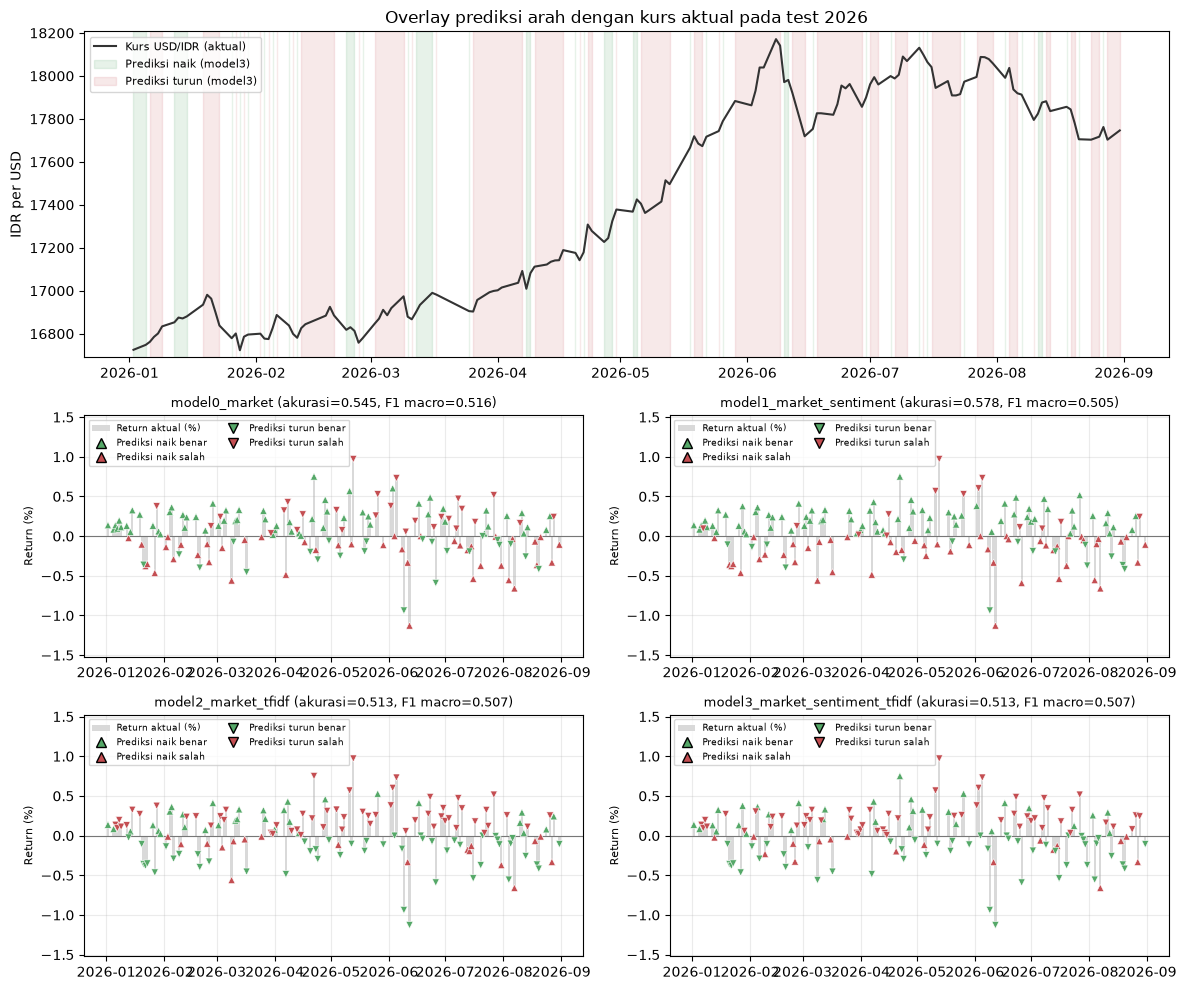

In [14]:
def plot_predictions_vs_actual(predictions_test):
    test_rates = pd.read_csv(TEST_CSV, parse_dates=["trading_date"])
    predictions = predictions_test.copy()
    predictions["trading_date"] = pd.to_datetime(predictions["trading_date"])

    fig = plt.figure(figsize=(12, 10))
    grid = fig.add_gridspec(3, 2, height_ratios=[1.35, 1, 1])
    ax_top = fig.add_subplot(grid[0, :])
    ax_top.plot(test_rates["trading_date"], test_rates["usd_idr_rate"], color="#333333", linewidth=1.5, label="Kurs USD/IDR (aktual)")
    model3 = predictions[predictions["model"] == "model3_market_sentiment_tfidf"].sort_values("trading_date")
    bottom = float(test_rates["usd_idr_rate"].min()) * 0.998
    top = float(test_rates["usd_idr_rate"].max()) * 1.002
    ax_top.fill_between(model3["trading_date"], bottom, top, where=model3["y_pred"].to_numpy() == 1, color="#55a868", alpha=0.14, label="Prediksi naik (model3)")
    ax_top.fill_between(model3["trading_date"], bottom, top, where=model3["y_pred"].to_numpy() == 0, color="#c44e52", alpha=0.12, label="Prediksi turun (model3)")
    ax_top.set_ylim(bottom, top)
    ax_top.set_ylabel("IDR per USD")
    ax_top.set_title("Overlay prediksi arah dengan kurs aktual pada test 2026")
    ax_top.legend(fontsize=8, loc="upper left")

    daily_with_return = daily_raw.copy()
    daily_with_return["next_return"] = daily_with_return["usd_idr_rate"].shift(-1) / daily_with_return["usd_idr_rate"] - 1.0
    model_names = [name for name in predictions["model"].unique() if name.startswith("model")]
    direction_axes = [fig.add_subplot(grid[row, col]) for row, col in [(1, 0), (1, 1), (2, 0), (2, 1)]]
    legend_handles = [
        Patch(facecolor="#d9d9d9", label="Return aktual (%)"),
        Line2D([], [], marker="^", color="none", markerfacecolor="#55a868", markersize=7, label="Prediksi naik benar"),
        Line2D([], [], marker="^", color="none", markerfacecolor="#c44e52", markersize=7, label="Prediksi naik salah"),
        Line2D([], [], marker="v", color="none", markerfacecolor="#55a868", markersize=7, label="Prediksi turun benar"),
        Line2D([], [], marker="v", color="none", markerfacecolor="#c44e52", markersize=7, label="Prediksi turun salah"),
    ]
    for ax, model_name in zip(direction_axes, model_names):
        group = predictions[predictions["model"] == model_name].sort_values("trading_date")
        group = group.merge(daily_with_return[["trading_date", "next_return"]], on="trading_date", how="left")
        returns = group["next_return"].to_numpy() * 100.0
        correct = (group["y_true"] == group["y_pred"]).to_numpy()
        ax.bar(group["trading_date"], returns, width=1.2, color="#d9d9d9", label="Return aktual (%)")
        ax.axhline(0, color="#777777", linewidth=0.8)
        for marker, mask in [("^", group["y_pred"].to_numpy() == 1), ("v", group["y_pred"].to_numpy() == 0)]:
            ax.scatter(group.loc[mask, "trading_date"], returns[mask], marker=marker, s=26, c=np.where(correct[mask], "#55a868", "#c44e52"), edgecolors="white", linewidths=0.4, zorder=3)
        accuracy = accuracy_score(group["y_true"], group["y_pred"])
        f1_macro = f1_score(group["y_true"], group["y_pred"], average="macro", zero_division=0)
        limit = max(float(np.nanmax(np.abs(returns))) * 1.35, 0.5)
        ax.set_ylim(-limit, limit)
        ax.set_ylabel("Return (%)", fontsize=8)
        ax.set_title(f"{model_name} (akurasi={accuracy:.3f}, F1 macro={f1_macro:.3f})", fontsize=9)
        ax.grid(alpha=0.25)
        ax.legend(handles=legend_handles, fontsize=6.3, loc="upper left", ncol=2)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "prediksi_vs_aktual_test.png", dpi=150)
    plt.show()


plot_predictions_vs_actual(predictions_test)

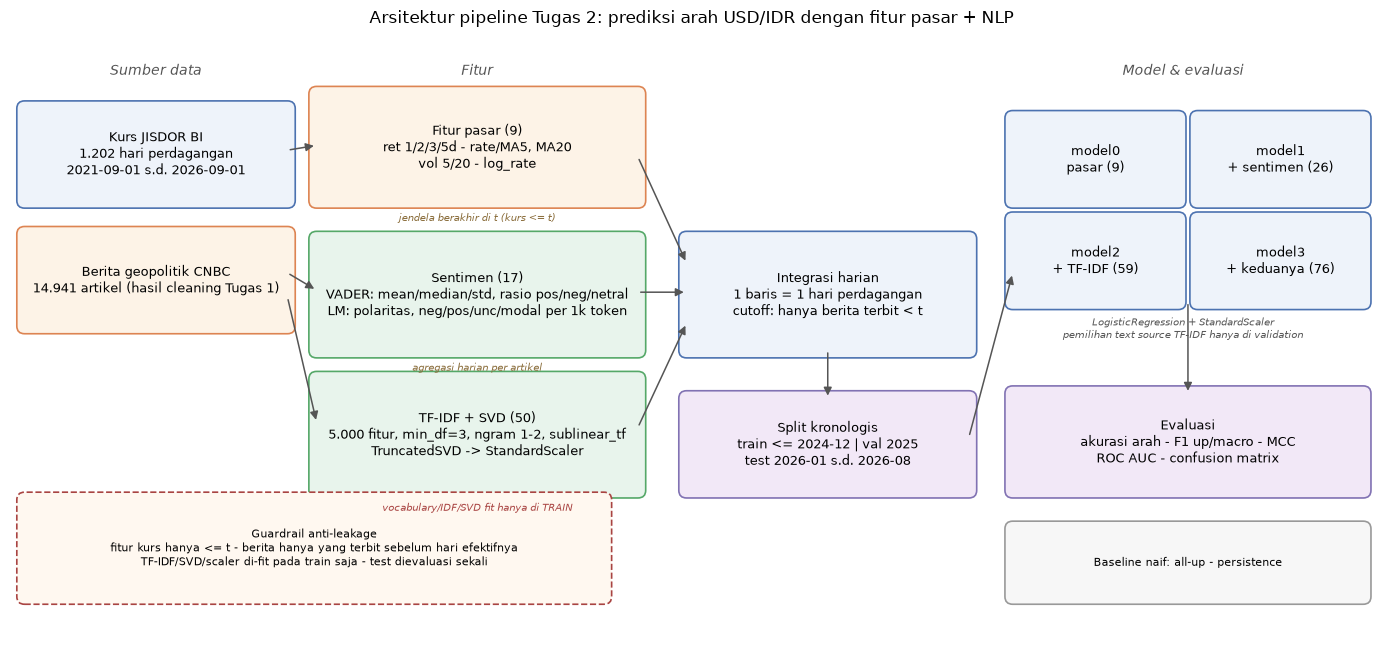

In [15]:
def draw_box(ax, x, y, width, height, text, facecolor="#eef3fa", edgecolor="#4c72b0", fontsize=9, dashed=False):
    box = FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.08", linewidth=1.2,
                         facecolor=facecolor, edgecolor=edgecolor, linestyle="--" if dashed else "-")
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=fontsize, wrap=True)


def draw_note(ax, x, y, text, color="#8a6d3b", fontsize=7.5):
    ax.text(x, y, text, ha="center", va="top", fontsize=fontsize, style="italic", color=color)


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12, color="#555555", linewidth=1.1)
    ax.add_patch(arrow)


def plot_pipeline_diagram():
    fig, ax = plt.subplots(figsize=(14, 6.6))
    ax.set_xlim(0, 14)
    ax.set_ylim(2.3, 8.6)
    ax.axis("off")

    # kolom 1: sumber data
    ax.text(1.5, 8.15, "Sumber data", fontsize=10, style="italic", color="#555555", ha="center")
    draw_box(ax, 0.15, 6.85, 2.7, 0.95, "Kurs JISDOR BI\n1.202 hari perdagangan\n2021-09-01 s.d. 2026-09-01")
    draw_box(ax, 0.15, 5.55, 2.7, 0.95, "Berita geopolitik CNBC\n14.941 artikel (hasil cleaning Tugas 1)",
             facecolor="#fdf3e7", edgecolor="#dd8452")

    # kolom 2: fitur
    ax.text(4.8, 8.15, "Fitur", fontsize=10, style="italic", color="#555555", ha="center")
    draw_box(ax, 3.15, 6.85, 3.3, 1.1, "Fitur pasar (9)\nret 1/2/3/5d - rate/MA5, MA20\nvol 5/20 - log_rate",
             facecolor="#fdf3e7", edgecolor="#dd8452")
    draw_note(ax, 4.8, 6.72, "jendela berakhir di t (kurs <= t)")
    draw_box(ax, 3.15, 5.30, 3.3, 1.15,
             "Sentimen (17)\nVADER: mean/median/std, rasio pos/neg/netral\nLM: polaritas, neg/pos/unc/modal per 1k token",
             facecolor="#e8f4ec", edgecolor="#55a868")
    draw_note(ax, 4.8, 5.17, "agregasi harian per artikel")
    draw_box(ax, 3.15, 3.85, 3.3, 1.15,
             "TF-IDF + SVD (50)\n5.000 fitur, min_df=3, ngram 1-2, sublinear_tf\nTruncatedSVD -> StandardScaler",
             facecolor="#e8f4ec", edgecolor="#55a868")
    draw_note(ax, 4.8, 3.72, "vocabulary/IDF/SVD fit hanya di TRAIN", color="#a94442")

    # integrasi + split
    draw_box(ax, 6.95, 5.30, 2.9, 1.15, "Integrasi harian\n1 baris = 1 hari perdagangan\ncutoff: hanya berita terbit < t")
    draw_box(ax, 6.95, 3.85, 2.9, 0.95, "Split kronologis\ntrain <= 2024-12 | val 2025\ntest 2026-01 s.d. 2026-08",
             facecolor="#f2e8f7", edgecolor="#8172b3")

    # kolom 3: model & evaluasi
    ax.text(12.05, 8.15, "Model & evaluasi", fontsize=10, style="italic", color="#555555", ha="center")
    draw_box(ax, 10.30, 6.85, 1.70, 0.85, "model0\npasar (9)")
    draw_box(ax, 12.20, 6.85, 1.70, 0.85, "model1\n+ sentimen (26)")
    draw_box(ax, 10.30, 5.80, 1.70, 0.85, "model2\n+ TF-IDF (59)")
    draw_box(ax, 12.20, 5.80, 1.70, 0.85, "model3\n+ keduanya (76)")
    draw_note(ax, 12.05, 5.65, "LogisticRegression + StandardScaler\npemilihan text source TF-IDF hanya di validation", color="#555555")
    draw_box(ax, 10.30, 3.85, 3.60, 1.00, "Evaluasi\nakurasi arah - F1 up/macro - MCC\nROC AUC - confusion matrix",
             facecolor="#f2e8f7", edgecolor="#8172b3")
    draw_box(ax, 10.30, 2.75, 3.60, 0.70, "Baseline naif: all-up - persistence",
             facecolor="#f7f7f7", edgecolor="#999999", fontsize=8)

    # guardrail anti-leakage
    draw_box(ax, 0.15, 2.75, 5.95, 1.00,
             "Guardrail anti-leakage\nfitur kurs hanya <= t - berita hanya yang terbit sebelum hari efektifnya\nTF-IDF/SVD/scaler di-fit pada train saja - test dievaluasi sekali",
             facecolor="#fff8f0", edgecolor="#a94442", dashed=True, fontsize=8)

    # panah
    draw_arrow(ax, (2.85, 7.37), (3.15, 7.42))
    draw_arrow(ax, (2.85, 6.10), (3.15, 5.92))
    draw_arrow(ax, (2.85, 5.85), (3.15, 4.55))
    draw_arrow(ax, (6.45, 7.30), (6.95, 6.20))
    draw_arrow(ax, (6.45, 5.90), (6.95, 5.90))
    draw_arrow(ax, (6.45, 4.50), (6.95, 5.58))
    draw_arrow(ax, (8.40, 5.30), (8.40, 4.80))
    draw_arrow(ax, (9.85, 4.40), (10.30, 6.10))
    draw_arrow(ax, (12.10, 5.80), (12.10, 4.85))

    ax.set_title("Arsitektur pipeline Tugas 2: prediksi arah USD/IDR dengan fitur pasar + NLP", fontsize=12)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "pipeline_tugas2.png", dpi=200)
    plt.show()


plot_pipeline_diagram()

## Langkah 11 - Analisis hasil

Rangkuman hasil test 2026 (angka lengkap ada di tabel Langkah 10):

1. **Market-only baseline**: akurasi arah ~54,5%, F1 macro ~0,516, AUC ~0,567 - hanya sedikit di atas acak dan masih di bawah baseline selalu-naik (~57,1%).
2. **Sentimen menambah sinyal?** Model1 memberi akurasi test tertinggi (~57,8%) dan F1 kelas naik ~0,695, tetapi F1 macro dan AUC justru turun, dan di validation akurasinya ~49%. Efek tidak stabil antar-split.
3. **TF-IDF menambah sinyal?** Model2 tidak memperbaiki apa pun: akurasi test ~51,3%, AUC ~0,548, bahkan di validation AUC di bawah acak.
4. **Sentimen + TF-IDF digabung?** Model3 punya AUC test tertinggi (~0,568) tetapi akurasi ~51,3% - tidak ada peningkatan yang meyakinkan dibanding model0.
5. **Overfitting / leakage / instabilitas?** Peringkat model berubah antara validation dan test, selisih antar model kecil dibanding ukuran test (n=154), dan semua metrik mendekati acak. Verifikasi leakage lolos, jadi pola ini paling tepat dijelaskan sebagai derau, bukan sinyal NLP yang stabil.

**Kesimpulan:** pada setup klasikal ini (VADER + LM + TF-IDF + regresi logistik) belum ada bukti bahwa informasi berita geopolitik menambah sinyal prediktif yang stabil untuk arah harian USD/IDR. Ini adalah baseline negatif yang jujur dan titik awal yang metodologis untuk eksperimen lanjutan.

Catatan pemilihan text source: `title+body` terpilih berdasarkan F1 macro validation, tetapi selisihnya dengan `title` sangat kecil (0,5231 vs 0,5201) dan `title` justru unggul pada akurasi/AUC - perbedaan ini berada dalam kisaran derau. Keputusan tetap dicatat eksplisit sebagai konfigurasi eksperimen, bukan klaim keunggulan.

## Konfigurasi eksperimen, reproduksi, dan limitasi

```text
TARGET          = next_day_direction (flat = 0)
TEXT_SOURCE     = title+body (dipilih via validation)
SENTIMENT       = enabled (VADER + Loughran-McDonald)
TFIDF           = enabled (max_features=5000, min_df=3, ngram 1-2, SVD 50)
MODEL           = LogisticRegression (StandardScaler, max_iter=5000)
RANDOM_SEED     = 42
TRAIN_PERIOD    = 2021-09-29 s/d 2024-12-31 (790 baris)
VALIDATION      = 2025-01-02 s/d 2025-12-31 (237 baris)
TEST            = 2026-01-02 s/d 2026-08-31 (154 baris)
```

Semua file output:

- `data/processed/train.csv`, `validation.csv`, `test.csv`, `audit_summary.json`
- `data/cleaned/news_sentiment.csv` (cache skor artikel)
- `reports/predictions_validation.csv`, `predictions_test.csv`
- `reports/results_validation.csv`, `results_test.csv`, `results_text_source.csv`
- `reports/figures/`: `eda_kurs_split.png`, `eda_berita.png`, `metrics_comparison_test.png`, `confusion_matrix_test.png`, `roc_test.png`, `prediksi_vs_aktual_test.png`, `pipeline_tugas2.png`

Versi modular dari logika yang sama ada di `src/` dan dipakai notebook 01 (EDA) dan 02 (eksperimen).

### Limitasi

- Test 2026 hanya 154 baris dan mencakup satu rezim pasar; selisih metrik antar model belum tentu stabil di periode lain.
- Leksikon tidak memahami konteks, ironi, atau negasi kompleks.
- TF-IDF harian + SVD 50 komponen adalah representasi sederhana; belum ada tuning hyperparameter (sesuai semangat baseline).
- Fitur berita hanya dari satu sumber (CNBC) dan bergantung pada kualitas filter geopolitik Tugas 1.
- Jumlah artikel per hari sangat bervariasi (rata-rata 12,4; maksimum 133), sehingga agregasi rata-rata bisa menenggelamkan artikel yang sangat berdampak.

In [16]:
output_paths = [
    TRAIN_CSV,
    VALIDATION_CSV,
    TEST_CSV,
    AUDIT_JSON,
    SENTIMENT_CSV,
    PREDICTIONS_VALIDATION_CSV,
    PREDICTIONS_TEST_CSV,
    RESULTS_VALIDATION_CSV,
    RESULTS_TEST_CSV,
    RESULTS_TEXT_SOURCE_CSV,
    FIGURES_DIR / "metrics_comparison_test.png",
    FIGURES_DIR / "confusion_matrix_test.png",
    FIGURES_DIR / "roc_test.png",
    FIGURES_DIR / "prediksi_vs_aktual_test.png",
    FIGURES_DIR / "pipeline_tugas2.png",
]

for path in output_paths:
    status = "OK" if path.exists() else "HILANG"
    print(f"[{status}] {path.relative_to(ROOT)}")

[OK] data\processed\train.csv
[OK] data\processed\validation.csv
[OK] data\processed\test.csv
[OK] data\processed\audit_summary.json
[OK] data\cleaned\news_sentiment.csv
[OK] reports\predictions_validation.csv
[OK] reports\predictions_test.csv
[OK] reports\results_validation.csv
[OK] reports\results_test.csv
[OK] reports\results_text_source.csv
[OK] reports\figures\metrics_comparison_test.png
[OK] reports\figures\confusion_matrix_test.png
[OK] reports\figures\roc_test.png
[OK] reports\figures\prediksi_vs_aktual_test.png
[OK] reports\figures\pipeline_tugas2.png
